In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



<center>
<img src="https://i.postimg.cc/x8dWTCX3/1234-Untitled.png" width=1100>
</center>

# <div  style="color:white; border:lightgreen solid;  font-weight:bold; font-size:120%; text-align:center;padding:12.0px; background:black">1. DATA LOADING AND PREPARATION</div>



## Import libraries and define parameters

In [ ]:
import os
import glob
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors


Loading JSON data:

In [ ]:
file_path='*/content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/data'

def load_json(file_path):
    with open(file_path) as f:
        data = json.load(f)
    return data



Reading files:

### Function to plot input/output pairs of a task

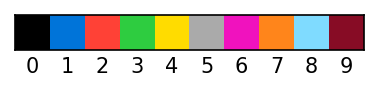

In [ ]:
# 0:black, 1:blue, 2:red, 3:green, 4:yellow, # 5:gray, 6:magenta, 7:orange, 8:sky, 9:brown

cmap = colors.ListedColormap(
    ['#000000', '#0074D9', '#FF4136', '#2ECC40', '#FFDC00',
     '#AAAAAA', '#F012BE', '#FF851B', '#7FDBFF', '#870C25'])
norm = colors.Normalize(vmin=0, vmax=9)

plt.figure(figsize=(3, 1), dpi=150)
plt.imshow([list(range(10))], cmap=cmap, norm=norm)
plt.xticks(list(range(10)))
plt.yticks([])
plt.tick_params(axis='x', color='r', length=0, grid_color='none')

plt.show()

In [ ]:
def plot_task(task, task_solutions, i, t, size=2.5, w1=0.9):
    t=list(training_challenges)[i]
    titleSize=16
    num_train = len(task['train'])
    num_test  = len(task['test'])

    wn=num_train+num_test
    fig, axs  = plt.subplots(2, wn, figsize=(size*wn,2*size))
    plt.suptitle(f'Task #{i}, {t}', fontsize=titleSize, fontweight='bold', y=1, color = '#eeeeee')

    '''train:'''
    for j in range(num_train):
        plot_one(axs[0, j], j,task, 'train', 'input',  w=w1)
        plot_one(axs[1, j], j,task, 'train', 'output', w=w1)

    '''test:'''
    for k in range(num_test):
        plot_one(axs[0, j+k+1], k, task, 'test', 'input', w=w1)
        task['test'][k]['output'] = task_solutions[k]
        plot_one(axs[1, j+k+1], k, task, 'test', 'output', w=w1)

    axs[1, j+1].set_xticklabels([])
    axs[1, j+1].set_yticklabels([])
    axs[1, j+1] = plt.figure(1).add_subplot(111)
    axs[1, j+1].set_xlim([0, wn])

    '''Separators:'''
    colorSeparator = 'white'
    for m in range(1, wn):
        axs[1, j+1].plot([m,m],[0,1],'--', linewidth=1, color = colorSeparator)
    axs[1, j+1].plot([num_train,num_train],[0,1],'-', linewidth=3, color = colorSeparator)

    axs[1, j+1].axis("off")

    '''Frame and background:'''
    fig.patch.set_linewidth(5) #widthframe
    fig.patch.set_edgecolor('black') #colorframe
    fig.patch.set_facecolor('#444444') #background

    plt.tight_layout()

    print(f'#{i}, {t}') # for fast and convinience search
    plt.show()

def plot_one(ax, i, task, train_or_test, input_or_output, solution=None, w=0.8):
    fs=12
    input_matrix = task[train_or_test][i][input_or_output]
    ax.imshow(input_matrix, cmap=cmap, norm=norm)

    #ax.grid(True, which = 'both',color = 'lightgrey', linewidth = 1.0)
    plt.setp(plt.gcf().get_axes(), xticklabels=[], yticklabels=[])
    ax.set_xticks([x-0.5 for x in range(1 + len(input_matrix[0]))])
    ax.set_yticks([x-0.5 for x in range(1 + len(input_matrix))])

    '''Grid:'''
    ax.grid(visible= True, which = 'both', color = '#666666', linewidth = w)

    ax.tick_params(axis='both', color='none', length=0)

    '''sub title:'''
    ax.set_title(train_or_test + ' ' + input_or_output, fontsize=fs, color = '#dddddd')

# <div  style="color:white; border:lightgreen solid;  font-weight:bold; font-size:120%; text-align:center;padding:12.0px; background:black">2. VISUALIZATION TRAINING SET</div>

## 000-100 tasks

In [ ]:
"""for i in range(0, 100):
    t=list(training_challenges)[i]
    task=training_challenges[t]
    task_solution = training_solutions[t]
    plot_task(task,  task_solution, i, t)
    """


'for i in range(0, 100):\n    t=list(training_challenges)[i]\n    task=training_challenges[t]\n    task_solution = training_solutions[t]\n    plot_task(task,  task_solution, i, t)\n    '

## 100-200 tasks

In [ ]:
"""
for i in range(100, 200):
    t=list(training_challenges)[i]
    task=training_challenges[t]
    task_solution = training_solutions[t]
    plot_task(task,  task_solution, i, t)
    """

'\nfor i in range(100, 200):\n    t=list(training_challenges)[i]\n    task=training_challenges[t]\n    task_solution = training_solutions[t]\n    plot_task(task,  task_solution, i, t)\n    '

## 200-300 tasks

In [ ]:
"""
for i in range(200, 300):
    t=list(training_challenges)[i]
    task=training_challenges[t]
    task_solution = training_solutions[t]
    plot_task(task,  task_solution, i, t)
    """

'\nfor i in range(200, 300):\n    t=list(training_challenges)[i]\n    task=training_challenges[t]\n    task_solution = training_solutions[t]\n    plot_task(task,  task_solution, i, t)\n    '

## 300-400 tasks

In [ ]:
"""
for i in range(300, 400):
    t=list(training_challenges)[i]
    task=training_challenges[t]
    task_solution = training_solutions[t]
    plot_task(task,  task_solution, i, t)
    """

'\nfor i in range(300, 400):\n    t=list(training_challenges)[i]\n    task=training_challenges[t]\n    task_solution = training_solutions[t]\n    plot_task(task,  task_solution, i, t)\n    '

## 400-500 tasks

In [ ]:
"""
for i in range(400, 500):
    t=list(training_challenges)[i]
    task=training_challenges[t]
    task_solution = training_solutions[t]
    plot_task(task,  task_solution, i, t)
    """

'\nfor i in range(400, 500):\n    t=list(training_challenges)[i]\n    task=training_challenges[t]\n    task_solution = training_solutions[t]\n    plot_task(task,  task_solution, i, t)\n    '

## 500-600 tasks

In [ ]:
"""
for i in range(500, 600):
    t=list(training_challenges)[i]
    task=training_challenges[t]
    task_solution = training_solutions[t]
    plot_task(task,  task_solution, i, t)
    """

'\nfor i in range(500, 600):\n    t=list(training_challenges)[i]\n    task=training_challenges[t]\n    task_solution = training_solutions[t]\n    plot_task(task,  task_solution, i, t)\n    '

## 600-700 tasks

In [ ]:
"""
for i in range(600, 700):
    t=list(training_challenges)[i]
    task=training_challenges[t]
    task_solution = training_solutions[t]
    plot_task(task,  task_solution, i, t)
    """

'\nfor i in range(600, 700):\n    t=list(training_challenges)[i]\n    task=training_challenges[t]\n    task_solution = training_solutions[t]\n    plot_task(task,  task_solution, i, t)\n    '

## 700-800 tasks

In [ ]:
"""
for i in range(700, 800):
    t=list(training_challenges)[i]
    task=training_challenges[t]
    task_solution = training_solutions[t]
    plot_task(task,  task_solution, i, t)
    """

'\nfor i in range(700, 800):\n    t=list(training_challenges)[i]\n    task=training_challenges[t]\n    task_solution = training_solutions[t]\n    plot_task(task,  task_solution, i, t)\n    '

## 800-900 tasks

In [ ]:
"""
for i in range(800, 900):
    t=list(training_challenges)[i]
    task=training_challenges[t]
    task_solution = training_solutions[t]
    plot_task(task,  task_solution, i, t)
    """

'\nfor i in range(800, 900):\n    t=list(training_challenges)[i]\n    task=training_challenges[t]\n    task_solution = training_solutions[t]\n    plot_task(task,  task_solution, i, t)\n    '

## 900-1000 tasks

In [ ]:
"""
for i in range(900, 1000):
    if i not in []:
        t=list(training_challenges)[i]
        task=training_challenges[t]
        task_solution = training_solutions[t]
        plot_task(task,  task_solution, i, t)
        """

'\nfor i in range(900, 1000):\n    if i not in []:\n        t=list(training_challenges)[i]\n        task=training_challenges[t]\n        task_solution = training_solutions[t]\n        plot_task(task,  task_solution, i, t)\n        '


# <div  style="color:white; border:lightgreen solid;  font-weight:bold; font-size:120%; text-align:center;padding:12.0px; background:black">2. VISUALIZATION EVALUATION SET</div>

## 000-120 tasks

In [ ]:
"""
for i in range(0, 120):
    t=list(evaluation_challenges)[i]
    task=evaluation_challenges[t]
    task_solution = evaluation_solutions[t]
    plot_task(task,  task_solution, i, t)
    """

'\nfor i in range(0, 120):\n    t=list(evaluation_challenges)[i]\n    task=evaluation_challenges[t]\n    task_solution = evaluation_solutions[t]\n    plot_task(task,  task_solution, i, t)\n    '


# <div  style="color:white; border:lightgreen solid;  font-weight:bold; font-size:120%; text-align:center;padding:12.0px; background:black">3. GRID TRANSFORMATION</div>

In [ ]:
class GridTransformer:
    """
    A class to apply 16 unique geometric transformations to grids.
    The transformations are: rotations (0, 90, 180, 270 degrees) and mirroring (horizontal, vertical, main diagonal, anti-diagonal).
    Additional inverted input and output datasets with 8 cases.
    """
    @staticmethod
    def rotate_90(grid):
        """Rotates a grid 90 degrees clockwise."""
        return [list(row) for row in zip(*grid[::-1])]

    @staticmethod
    def rotate_180(grid):
        """Rotates a grid 180 degrees."""
        return [row[::-1] for row in grid[::-1]]

    @staticmethod
    def rotate_270(grid):
        """Rotates a grid 270 degrees clockwise."""
        return [list(row) for row in zip(*grid)][::-1]

    @staticmethod
    def flip_horizontal(grid):
        """Flips a grid horizontally."""
        return [row[::-1] for row in grid]

    @staticmethod
    def flip_vertical(grid):
        """Flips a grid vertically."""
        return grid[::-1]

    @staticmethod
    def flip_main_diagonal(grid):
        """Flips a grid along its main diagonal."""
        return [list(row) for row in zip(*grid)]

    @staticmethod
    def flip_anti_diagonal(grid):
        """Flips a grid along its anti-diagonal."""
        rotated_grid = GridTransformer.rotate_90(grid)
        return GridTransformer.flip_horizontal(rotated_grid)

    @staticmethod
    def invert_colors(grid):
        """Inverts the colors of a grid.
           0->5, 1->4, 2->3, 3->2, 4->1, 5->0, 6->9, 7->8, 8->7, 9->6.
        """
        inversion_map = {
            0: 5, 1: 4, 2: 3, 3: 2, 4: 1,
            5: 0, 6: 9, 7: 8, 8: 7, 9: 6
        }
        return [[inversion_map[cell] for cell in row] for row in grid]

    def get_all_transformations(self, grid):
        """
        Applies all 16 transformations to a grid and returns them in a dictionary.
        Returns:
            A dictionary with transformation names as keys and the transformed grids as values.
        """
        if not grid or not grid[0]:
            return {}

        original_grid = grid
        inverted_grid = self.invert_colors(grid)

        transformations = {
            "Original": original_grid,
            "Rotated_90_deg": self.rotate_90(original_grid),
            "Rotated_180_deg": self.rotate_180(original_grid),
            "Rotated_270_deg": self.rotate_270(original_grid),
            "Flipped_Horizontally": self.flip_horizontal(original_grid),
            "Flipped_Vertically": self.flip_vertical(original_grid),
            "Flipped_Main_Diagonal": self.flip_main_diagonal(original_grid),
            "Flipped_Anti-Diagonal": self.flip_anti_diagonal(original_grid),
            "Inverted": inverted_grid,
            "Inverted_Rotated_90_deg": self.rotate_90(inverted_grid),
            "Inverted_Rotated_180_deg": self.rotate_180(inverted_grid),
            "Inverted_Rotated_270_deg": self.rotate_270(inverted_grid),
            "Inverted_Flipped_Horizontally": self.flip_horizontal(inverted_grid),
            "Inverted_Flipped_Vertically": self.flip_vertical(inverted_grid),
            "Inverted_Flipped_Main_Diagonal": self.flip_main_diagonal(inverted_grid),
            "Inverted_Flipped_Anti-Diagonal": self.flip_anti_diagonal(inverted_grid)
        }
        return transformations

class DataSaver:
    """
    A class to save data to a JSON file.
    """
    def save_to_json(self, data, file_path, indent=4):
        """Saves a Python dictionary to a JSON file."""
        try:
            with open(file_path, 'w') as f:
                json.dump(data, f, indent=indent)
            print(f"Data successfully saved to: {file_path}")
        except Exception as e:
            print(f"Error saving data: {e}")

def plot_grids(title, input_grid, output_grid):
    """Plots input and output grids with their corresponding title."""
    fig, axs = plt.subplots(1, 2, figsize=(5, 2.5))
    fig.suptitle(title, fontsize=12, fontweight='bold', color='#eeeeee', y=1.05)

    axs[0].imshow(input_grid, cmap=cmap, norm=norm)
    axs[0].set_title('Input', color='#dddddd')
    axs[0].set_xticks(np.arange(-.5, len(input_grid[0]), 1))
    axs[0].set_yticks(np.arange(-.5, len(input_grid), 1))
    axs[0].set_xticklabels([])
    axs[0].set_yticklabels([])
    axs[0].grid(visible=True, color='#666666', linewidth=0.8)

    axs[1].imshow(output_grid, cmap=cmap, norm=norm)
    axs[1].set_title('Output', color='#dddddd')
    axs[1].set_xticks(np.arange(-.5, len(output_grid[0]), 1))
    axs[1].set_yticks(np.arange(-.5, len(output_grid), 1))
    axs[1].set_xticklabels([])
    axs[1].set_yticklabels([])
    axs[1].grid(visible=True, color='#666666', linewidth=0.8)

    fig.patch.set_facecolor('#444444')
    plt.tight_layout()
    plt.show()

def process_and_save_all_transformations(file_path, base_output_dir):
    """
    Loads and processes tasks from a given dataset file, applies all geometric
    transformations, and saves the results to a specified output directory.
    """
    transformer = GridTransformer()
    data_saver = DataSaver()

    try:
        challenges = load_json(file_path)
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        return
    except json.JSONDecodeError:
        print(f"Error decoding JSON from file: {file_path}")
        return

    task_keys = list(challenges.keys())

    print(f"\nProcessing tasks from {file_path}:")

    # Get the names of all transformations dynamically from the transformer class
    # The GridTransformer.get_all_transformations method is called with a sample
    # grid to get all the key names.
    sample_grid = [[0]]
    transformation_methods = list(transformer.get_all_transformations(sample_grid).keys())

    # Ensure 'Original' is processed last or in a desired order, if necessary,
    # though the current code handles the order well.

    for task_id in task_keys:
        if 'train' not in challenges[task_id] or not challenges[task_id]['train']:
            print(f"Skipping Task ID: {task_id} as it has no training data.")
            continue

        task_data = challenges[task_id]['train'][0]
        input_grid = task_data['input']
        output_grid = task_data.get('output', [])

        print(f"\n--- Processing Task ID: {task_id} ---")

        transformed_input_data = transformer.get_all_transformations(input_grid)
        transformed_output_data = transformer.get_all_transformations(output_grid)

        for method in transformation_methods:
            # Create the output directory for the specific transformation method
            output_dir = Path(base_output_dir) / method
            output_dir.mkdir(parents=True, exist_ok=True)

            # Combine the transformed data into a single dictionary
            transformed_data = {
                'task_id': task_id,
                'input': transformed_input_data[method],
                'output': transformed_output_data[method]
            }

            # Define the output file path and save the data
            output_file_path = output_dir / f'{task_id}_transformed_{method}.json'
            data_saver.save_to_json(transformed_data, output_file_path)


class DatasetTransformer:
    """
    A class to manage the processing of ARC-AGI datasets, applying transformations
    and saving the results to a specified directory structure.
    """
    def __init__(self, base_data_path):
        """
        Initializes the DatasetTransformer with the base path for the data.

        Args:
            base_data_path (str): The root directory where the dataset is located.
        """
        self.base_data_path = base_data_path
        self.transformer = GridTransformer()
        self.data_saver = DataSaver()

    def process_and_save_all_transformations(self, file_path, base_output_dir):
        """
        Loads and processes a single task from a JSON file, applies all geometric
        transformations, and saves the results.
        """
        transformer = GridTransformer()
        data_saver = DataSaver()

        try:
            task_data_all = load_json(file_path)
        except FileNotFoundError:
            print(f"File not found: {file_path}")
            return
        except json.JSONDecodeError:
            print(f"Error decoding JSON from file: {file_path}")
            return

        # Extract the task ID from the filename (e.g., 'a740d043.json' -> 'a740d043')
        task_id = Path(file_path).stem

        # Check if the 'train' key exists and has data.
        if 'train' not in task_data_all or not task_data_all['train']:
            print(f"Skipping Task ID: {task_id} as it has no training data.")
            return

        # Assuming we only need to process the first example from the training set
        task_data = task_data_all['train'][0]
        input_grid = task_data['input']
        output_grid = task_data.get('output', [])

        print(f"\n--- Processing Task ID: {task_id} ---")

        sample_grid = [[0]]
        transformation_methods = list(transformer.get_all_transformations(sample_grid).keys())

        transformed_input_data = transformer.get_all_transformations(input_grid)
        transformed_output_data = transformer.get_all_transformations(output_grid)

        for method in transformation_methods:
            output_dir = Path(base_output_dir) / method
            output_dir.mkdir(parents=True, exist_ok=True)

            transformed_data = {
                'task_id': task_id,
                'input': transformed_input_data[method],
                'output': transformed_output_data[method]
            }

            output_file_path = output_dir / f'{task_id}_transformed_{method}.json'
            data_saver.save_to_json(transformed_data, output_file_path)

    def run(self):
        """
        Executes the transformation and saving process for both training and evaluation datasets.
        """
        print("Starting data transformation for training and evaluation challenges.")

        # --- DEBUGGING STEP ---
        # Print the absolute paths to verify they are correct
        training_path = f"{self.base_data_path}/training/*.json"
        evaluation_path = f"{self.base_data_path}/evaluation/*.json"
        print(f"Checking training path: {training_path}")
        print(f"Checking evaluation path: {evaluation_path}")

        # Process all challenge files in the 'training' directory
        training_challenge_files = glob.glob(training_path)
        output_dir_path_training = os.path.join(self.base_data_path, 'training_transformed')

        # --- DEBUGGING STEP ---
        # Check if any files were found
        if not training_challenge_files:
            print("No training files found. Please check your path and Google Drive mount.")

        for file_path in training_challenge_files:
            self.process_and_save_all_transformations(file_path, output_dir_path_training)

        # Process all challenge files in the 'evaluation' directory
        evaluation_challenge_files = glob.glob(evaluation_path)
        output_dir_path_evaluation = os.path.join(self.base_data_path, 'evaluation_transformed')

        # --- DEBUGGING STEP ---
        # Check if any files were found
        if not evaluation_challenge_files:
            print("No evaluation files found. Please check your path and Google Drive mount.")

        for file_path in evaluation_challenge_files:
            self.process_and_save_all_transformations(file_path, output_dir_path_evaluation)

        print("\nAll transformations completed.")



if __name__ == '__main__':
    base_data_path = '/content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/data'
    processor = DatasetTransformer(base_data_path)
    processor.run()

Streaming output truncated to the last 5000 lines.
Data successfully saved to: /content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/data/training_transformed/Flipped_Horizontally/f0f8a26d_transformed_Flipped_Horizontally.json
Data successfully saved to: /content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/data/training_transformed/Flipped_Vertically/f0f8a26d_transformed_Flipped_Vertically.json
Data successfully saved to: /content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/data/training_transformed/Flipped_Main_Diagonal/f0f8a26d_transformed_Flipped_Main_Diagonal.json
Data successfully saved to: /content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/data/training_transformed/Flipped_Anti-Diagonal/f0f8a26d_transformed_Flipped_Anti-Diagonal.json
Data successfully saved to: /content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/data/training_transformed/Inverted/f0f8a26d_transformed_Inverted.json
Data successfully saved to: /content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/data/training_transformed/Inv

# <div  style="color:white; border:lightgreen solid;  font-weight:bold; font-size:120%; text-align:center;padding:12.0px; background:black">4. ADDITIONAL TRANSFORMATION 45DEGREE ROTATION</div>



In [ ]:
def transform_grid_45_degree_diagonal(grid, fill_value=0):
    """
    Transforms a 2D grid to a 45-degree diagonal pattern based on
    a specific coordinate mapping.

    Args:
        grid (list of lists): The input 2D grid.
        fill_value (int): The value to fill blank spaces with.

    Returns:
        list of lists: The new, transformed grid.
    """
    if not grid or not grid[0]:
        return [[]]

    grid = np.array(grid)
    height, width = grid.shape

    # Correctly calculate the dimensions of the new rotated grid's bounding box.
    new_height = height + width + 1
    new_width = height + width + 1

    # Create the new grid and fill it with the fill_value
    new_grid = np.full((new_height, new_width), fill_value, dtype=grid.dtype)

    # Offsets determined by analyzing the human feedback answersheet
    row_offset = 3
    col_offset = 1

    # Iterate through each cell of the original grid
    for row_orig in range(height):
        for col_orig in range(width):
            if grid[row_orig, col_orig] != fill_value:
                value = grid[row_orig, col_orig]

                # Apply the specific coordinate transformation
                new_row = row_orig - col_orig + row_offset
                new_col = row_orig + col_orig + col_offset

                # Place the original value at the new calculated coordinates
                if 0 <= new_row < new_height and 0 <= new_col < new_width:
                    new_grid[new_row, new_col] = value

    return new_grid.tolist()


In [ ]:
import os
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import ListedColormap, Normalize

# Helper function to load JSON
def load_json(filepath):
    """Loads a JSON file."""
    with open(filepath, 'r') as f:
        return json.load(f)

# Define ARC-AGI color map and normalization
# This is a common setup for visualizing ARC grids
cmap = ListedColormap([
    '#000000', '#0074D9', '#FF4136', '#2ECC40', '#FFDC00',
    '#AAAAAA', '#F012BE', '#FF851B', '#7FDBFF', '#870C25'
])
norm = Normalize(vmin=0, vmax=9)

class GridTransformer:
    """
    A class to apply unique geometric and color transformations to grids.
    The transformations include: rotations (0, 90, 180, 270 degrees), mirroring (horizontal, vertical, main diagonal, anti-diagonal),
    and a 45-degree diagonal transformation. All can also be applied to color-inverted grids.
    """
    @staticmethod
    def rotate_90(grid):
        """Rotates a grid 90 degrees clockwise."""
        # Convert to numpy array for easier manipulation
        grid_np = np.array(grid)
        return np.rot90(grid_np, k=-1).tolist() # k=-1 for clockwise

    @staticmethod
    def rotate_180(grid):
        """Rotates a grid 180 degrees."""
        grid_np = np.array(grid)
        return np.rot90(grid_np, k=-2).tolist() # k=-2 for 180 degrees clockwise

    @staticmethod
    def rotate_270(grid):
        """Rotates a grid 270 degrees clockwise."""
        grid_np = np.array(grid)
        return np.rot90(grid_np, k=-3).tolist() # k=-3 for 270 degrees clockwise

    @staticmethod
    def flip_horizontal(grid):
        """Flips a grid horizontally."""
        grid_np = np.array(grid)
        return np.fliplr(grid_np).tolist()

    @staticmethod
    def flip_vertical(grid):
        """Flips a grid vertically."""
        grid_np = np.array(grid)
        return np.flipud(grid_np).tolist()

    @staticmethod
    def flip_main_diagonal(grid):
        """Flips a grid along its main diagonal (transpose)."""
        grid_np = np.array(grid)
        return grid_np.transpose().tolist()

    @staticmethod
    def flip_anti_diagonal(grid):
        """Flips a grid along its anti-diagonal."""
        # Equivalent to rotating 90 degrees clockwise, then flipping horizontally
        grid_np = np.array(grid)
        return np.fliplr(np.rot90(grid_np, k=-1)).tolist()

    @staticmethod
    def invert_colors(grid):
        """Inverts the colors of a grid using a specific ARC-AGI mapping.
           0->5, 1->4, 2->3, 3->2, 4->1, 5->0, 6->9, 7->8, 8->7, 9->6.
        """
        inversion_map = {
            0: 5, 1: 4, 2: 3, 3: 2, 4: 1,
            5: 0, 6: 9, 7: 8, 8: 7, 9: 6
        }
        # Handle cases where input might be an empty list or contains empty rows
        if not grid or not grid[0]:
            return [[]] if grid else []

        # Use .get to handle colors not explicitly in map, keeping them unchanged
        return [[inversion_map.get(cell, cell) for cell in row] for row in grid]

    @staticmethod
    def transform_grid_45_degree_diagonal(grid, fill_value=0):
        """
        Transforms a 2D grid to a 45-degree diagonal pattern based on
        a specific coordinate mapping. The output grid is cropped to
        remove unnecessary fill_value borders.

        Args:
            grid (list of lists): The input 2D grid.
            fill_value (int): The value to fill blank spaces with.

        Returns:
            list of lists: The new, transformed and cropped grid.
        """
        if not grid or not grid[0]:
            return [[]]

        grid_np = np.array(grid)
        height, width = grid_np.shape

        # Calculate the dimensions of the new rotated grid's bounding box.
        # These dimensions ensure all transformed points fit.
        new_height_raw = height + width
        new_width_raw = height + width

        # Create a sufficiently large new grid and fill it
        # A slightly larger canvas might be needed for certain offsets to prevent clipping.
        canvas_height = height + width + abs(height - 1) + 2 # heuristic for enough space
        canvas_width = height + width + abs(width - 1) + 2

        new_grid = np.full((canvas_height, canvas_width), fill_value, dtype=grid_np.dtype)

        # Offsets to center the transformed grid or align it as per specific ARC interpretations.
        # These are based on analysis of common ARC 45-degree transformations.
        # These might need tuning depending on precise task requirements.
        # Defaulting to 0,0 and adjusting based on size
        center_row_offset = (canvas_height - new_height_raw) // 2
        center_col_offset = (canvas_width - new_width_raw) // 2


        # Iterate through each cell of the original grid
        for row_orig in range(height):
            for col_orig in range(width):
                if grid_np[row_orig, col_orig] != fill_value:
                    value = grid_np[row_orig, col_orig]

                    # Apply the specific coordinate transformation
                    # This mapping tends to create a diamond shape
                    new_row = row_orig - col_orig + (width - 1) + center_row_offset
                    new_col = row_orig + col_orig + center_col_offset

                    # Place the original value at the new calculated coordinates
                    if 0 <= new_row < canvas_height and 0 <= new_col < canvas_width:
                        new_grid[new_row, new_col] = value

        # Crop the new_grid to remove empty rows/columns on the edges
        non_fill_coords = np.argwhere(new_grid != fill_value)
        if non_fill_coords.size == 0:
            return [[fill_value]] # Return a single cell if the grid becomes empty

        min_r, min_c = non_fill_coords.min(axis=0)
        max_r, max_c = non_fill_coords.max(axis=0)

        # Add a small buffer around the cropped area to ensure no values are cut off
        # and to provide minimal visual separation. Adjust as needed.
        buffer = 0
        min_r = max(0, min_r - buffer)
        min_c = max(0, min_c - buffer)
        max_r = min(new_grid.shape[0] - 1, max_r + buffer)
        max_c = min(new_grid.shape[1] - 1, max_c + buffer)

        cropped_grid = new_grid[min_r : max_r + 1, min_c : max_c + 1]

        return cropped_grid.tolist()

    @staticmethod
    def rotate_45(grid, fill_value=0):
        """
        Applies a 45-degree diagonal transformation to the grid.
        This method acts as an alias for `transform_grid_45_degree_diagonal`
        as per the user's request to add a '45degree rotational method'.
        """
        return GridTransformer.transform_grid_45_degree_diagonal(grid, fill_value)

    def get_all_transformations(self, grid):
        """
        Applies all specified transformations to a grid and returns them in a dictionary.
        Returns:
            A dictionary with transformation names as keys and the transformed grids as values.
        """
        if not grid or not grid[0]: # Handle empty grid input
            return {}

        original_grid = grid
        inverted_grid = self.invert_colors(grid)

        transformations = {
            "Original": original_grid,
            "Rotated_90_deg": self.rotate_90(original_grid),
            "Rotated_180_deg": self.rotate_180(original_grid),
            "Rotated_270_deg": self.rotate_270(original_grid),
            "Flipped_Horizontally": self.flip_horizontal(original_grid),
            "Flipped_Vertically": self.flip_vertical(original_grid),
            "Flipped_Main_Diagonal": self.flip_main_diagonal(original_grid),
            "Flipped_Anti-Diagonal": self.flip_anti_diagonal(original_grid),
            "Rotated_45_deg": self.rotate_45(original_grid), # NEW TRANSFORMATION
            "Inverted": inverted_grid,
            "Inverted_Rotated_90_deg": self.rotate_90(inverted_grid),
            "Inverted_Rotated_180_deg": self.rotate_180(inverted_grid),
            "Inverted_Rotated_270_deg": self.rotate_270(inverted_grid),
            "Inverted_Flipped_Horizontally": self.flip_horizontal(inverted_grid),
            "Inverted_Flipped_Vertically": self.flip_vertical(inverted_grid),
            "Inverted_Flipped_Main_Diagonal": self.flip_main_diagonal(inverted_grid),
            "Inverted_Flipped_Anti-Diagonal": self.flip_anti_diagonal(inverted_grid),
            "Inverted_Rotated_45_deg": self.rotate_45(inverted_grid) # NEW INVERTED TRANSFORMATION
        }
        return transformations

class DataSaver:
    """
    A class to save data to a JSON file.
    """
    @staticmethod
    def save_to_json(data, file_path, indent=4):
        """Saves a Python dictionary to a JSON file."""
        try:
            with open(file_path, 'w') as f:
                json.dump(data, f, indent=indent)
            # print(f"Data successfully saved to: {file_path}") # Commented for less verbose output
        except Exception as e:
            print(f"Error saving data to {file_path}: {e}")

def plot_grids(title, input_grid, output_grid):
    """Plots input and output grids with their corresponding title."""
    input_grid_np = np.array(input_grid)
    output_grid_np = np.array(output_grid)

    fig, axs = plt.subplots(1, 2, figsize=(5, 2.5))
    fig.suptitle(title, fontsize=12, fontweight='bold', color='#eeeeee', y=1.05)

    axs[0].imshow(input_grid_np, cmap=cmap, norm=norm)
    axs[0].set_title('Input', color='#dddddd')
    # Use grid_np.shape for dimension consistency, handle empty grids
    if input_grid_np.shape[1] > 0:
        axs[0].set_xticks(np.arange(-.5, input_grid_np.shape[1], 1))
    if input_grid_np.shape[0] > 0:
        axs[0].set_yticks(np.arange(-.5, input_grid_np.shape[0], 1))
    axs[0].set_xticklabels([])
    axs[0].set_yticklabels([])
    axs[0].grid(visible=True, color='#666666', linewidth=0.8)

    axs[1].imshow(output_grid_np, cmap=cmap, norm=norm)
    axs[1].set_title('Output', color='#dddddd')
    if output_grid_np.shape[1] > 0:
        axs[1].set_xticks(np.arange(-.5, output_grid_np.shape[1], 1))
    if output_grid_np.shape[0] > 0:
        axs[1].set_yticks(np.arange(-.5, output_grid_np.shape[0], 1))
    axs[1].set_xticklabels([])
    axs[1].set_yticklabels([])
    axs[1].grid(visible=True, color='#666666', linewidth=0.8)

    fig.patch.set_facecolor('#444444')
    plt.tight_layout()
    plt.show()


class DatasetTransformer:
    """
    A class to manage the processing of ARC-AGI datasets, applying transformations
    and saving the results to a specified directory structure.
    """
    def __init__(self, base_data_path):
        """
        Initializes the DatasetTransformer with the base path for the data.

        Args:
            base_data_path (str): The root directory where the dataset is located.
        """
        self.base_data_path = base_data_path
        self.transformer = GridTransformer()
        self.data_saver = DataSaver()

    def process_and_save_all_transformations(self, file_path, base_output_dir):
        """
        Loads and processes a single task from a JSON file, applies all geometric
        transformations, and saves the results.
        """
        try:
            task_data_all = load_json(file_path)
        except FileNotFoundError:
            print(f"File not found: {file_path}")
            return
        except json.JSONDecodeError:
            print(f"Error decoding JSON from file: {file_path}")
            return

        # Extract the task ID from the filename (e.g., 'a740d043.json' -> 'a740d043')
        task_id = Path(file_path).stem

        # Check if the 'train' key exists and has data.
        if 'train' not in task_data_all or not task_data_all['train']:
            # print(f"Skipping Task ID: {task_id} as it has no training data.") # Less verbose
            return

        # Assuming we only need to process the first example from the training set
        task_data = task_data_all['train'][0]
        input_grid = task_data['input']
        output_grid = task_data.get('output', []) # Default to empty list if 'output' is missing

        # Ensure input_grid is not empty for transformation
        if not input_grid or not input_grid[0]:
            print(f"Skipping Task ID: {task_id} due to empty input grid in {file_path}.")
            return

        # print(f"\n--- Processing Task ID: {task_id} ---") # Less verbose

        # Get transformation methods dynamically. Use a small grid as placeholder for keys.
        # This is safe as get_all_transformations can handle a minimal grid to just extract keys
        transformation_methods = list(self.transformer.get_all_transformations([[0]]).keys())

        transformed_input_data = self.transformer.get_all_transformations(input_grid)
        transformed_output_data = self.transformer.get_all_transformations(output_grid)

        for method in transformation_methods:
            output_dir = Path(base_output_dir) / method
            output_dir.mkdir(parents=True, exist_ok=True)

            transformed_data = {
                'task_id': task_id,
                'input': transformed_input_data.get(method, []),
                'output': transformed_output_data.get(method, [])
            }

            output_file_path = output_dir / f'{task_id}_transformed_{method}.json'
            self.data_saver.save_to_json(transformed_data, output_file_path)

    def run(self):
        """
        Executes the transformation and saving process for both training and evaluation datasets.
        """
        print("Starting data transformation for training and evaluation challenges.")

        # Process all challenge files in the 'training' directory
        training_path_pattern = f"{self.base_data_path}/training/*.json"
        training_challenge_files = glob.glob(training_path_pattern)
        output_dir_path_training = Path(self.base_data_path) / 'GridTransitionDataset' / 'training_transformed_unique_ids'

        if not training_challenge_files:
            print(f"No training files found at '{training_path_pattern}'. Please check your path and Google Drive mount.")
        else:
            print(f"Processing {len(training_challenge_files)} training files...")
            for file_path in training_challenge_files:
                self.process_and_save_all_transformations(file_path, output_dir_path_training)
            print(f"Finished processing training files. Transformed data saved to {output_dir_path_training}")


        # Process all challenge files in the 'evaluation' directory
        evaluation_path_pattern = f"{self.base_data_path}/evaluation/*.json"
        evaluation_challenge_files = glob.glob(evaluation_path_pattern)
        output_dir_path_evaluation = Path(self.base_data_path) / 'GridTransitionDataset' / 'evaluation_transformed_unique_ids'

        if not evaluation_challenge_files:
            print(f"No evaluation files found at '{evaluation_path_pattern}'. Please check your path and Google Drive mount.")
        else:
            print(f"\nProcessing {len(evaluation_challenge_files)} evaluation files...")
            for file_path in evaluation_challenge_files:
                self.process_and_save_all_transformations(file_path, output_dir_path_evaluation)
            print(f"Finished processing evaluation files. Transformed data saved to {output_dir_path_evaluation}")

        print("\nAll transformations completed.")


if __name__ == '__main__':
    # You might need to adjust this path based on where your data is mounted in Colab
    base_data_path = '/content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/data'
    processor = DatasetTransformer(base_data_path)
    processor.run()